# Fine-tuning U-Net architecture — modèles 2,5D (séquentiels)
Notebook dédié à CSA-Net avec des triplets ordonnés de coupes échographiques
d'un même poisson, conformément au protocole 2,5D de l'article :
- CSA-Net

In [1]:
import os
import numpy as np
import torch
import torch.optim as optim
import pickle
import time
import sys
import pandas as pd
import random

from torch.utils.data import DataLoader, Dataset
from matplotlib import pyplot as plt
from pathlib import Path
from sklearn.model_selection import StratifiedGroupKFold

sys.path.append(str(Path.cwd().parent))

from utils.models_config import (
    split_dataset, dataset_to_dict, metrics_by_class,
    save_validation_masks, save_validation_overlays,
)
from utils.post_traitement import keep_largest_components, fill_holes
from utils.stats_fct import plot_segmentation_comparison
from utils.fonctions_de_perte import BCE_Dice_ContourLoss_ignore
from utils.dataset_unet import RoboflowUNetDataset
from utils.data_augmentation_fct import data_augmentation_sequence
from models.CSANet import CSANet


/home/ldepiero/Stage-GonAIde-2026/mon_venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Gestion de la classe 'ignore' :
# True  -> les pixels ignore sont exclus de la loss et des métriques
# False -> les pixels ignore sont considérés comme du fond
IGNORE = True

# Seed global pour la reproductibilité des résultats
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


### Choix du modèle

In [3]:
MODEL_NAME = "CSANet"

### Importation et traitement des données

In [4]:
# -------- 1. Importation des images et annotations --------
DATASET_NAME = "3classes"
DATASET_CONFIG = {
    "3classes": {
        "images": "../data/COCO/images/cavite",
        "annotations": "../data/COCO/labels/cavite/annotations.json",
    },
}
images_dir = DATASET_CONFIG[DATASET_NAME]["images"]
annotations_json = DATASET_CONFIG[DATASET_NAME]["annotations"]

# ------- 2. Création des répertoires de sortie --------
masks_dir = f"masks/eval/{MODEL_NAME}/{DATASET_NAME}"
results_dir = f"results/eval/{MODEL_NAME}/{DATASET_NAME}"
os.makedirs(masks_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

# ------- 3. Importation des métadonnées --------
df = pd.read_excel(
    "../utils/correspondance_echo_final.xlsx",
    dtype={"annee": str, "image_id": str, "new_name_file": str},
)

# -------- 4. Préparation du dataset --------
all_samples, categories, num_classes, class_ids, ignore_category_id = dataset_to_dict(
    df, annotations_json, images_dir
)
gonade_id = class_ids.index(
    next((cid for cid, label in categories.items() if label == "Gonade"), class_ids[0])
) if ignore_category_id is not None else None
class_names = [categories[cid] for cid in class_ids]
ignore_mode = "pixels ignore exclus de la loss et des métriques" if IGNORE else "pixels ignore considérés comme fond"
print(f"Model : {MODEL_NAME}, Dataset : {DATASET_NAME}, classes={class_names}")
print(f"IGNORE={IGNORE} : {ignore_mode}")


Classes détectées (3) : {1: 'Cavite', 2: 'Gonade', 3: 'Intestin'}
Catégorie ignore détectée : 'ignore' (id=4)
Model : CSANet, Dataset : 3classes, classes=['Cavite', 'Gonade', 'Intestin']
IGNORE=True : pixels ignore exclus de la loss et des métriques


### Division du jeu de données

In [5]:
IMAGE_SIZE = (512, 512)

cv_samples, test_samples, cv_categories, test_categories, groups_train, groups_test = split_dataset(all_samples)

Nombre total d'images valides : 169
Échantillons train/val        : 145
Échantillons de test          : 24


## CSA-Net — dépendance entre coupes échographiques

Les architectures précédentes traitent chaque image indépendamment. Or les images d'un même poisson forment une **séquence de coupes échographiques ordonnées** (voir `position` / `position_ratio` dans les métadonnées), qui s'apparente à un volume 3D pseudo-continu.

- Chaque coupe de la séquence est encodée indépendamment par l'encodeur ResNet34 (poids partagés entre les coupes).
- Les features du **bottleneck** (la représentation la plus profonde) sont mélangées le long de la dimension des coupes `T`, pour propager le contexte entre coupes voisines.
- Chaque coupe est ensuite décodée indépendamment par le décodeur U-Net habituel (skip connections non mélangées).

Entrée attendue : `(B, T, C, H, W)` — un batch de `B` séquences de `T` coupes RGB `(C=3, H=512, W=512)`.
Sortie : `(B, T, num_classes, H, W)` — un masque multi-classes par coupe.

### Dataset de triplets centrés (`CenterTripletDataset`)

Chaque échantillon regroupe la coupe précédente, la coupe centrale et la coupe suivante
d'un même poisson, triées par `position_ratio` (repli sur `position`). Le masque cible
est uniquement celui de la coupe centrale, comme dans l'article CSA-Net.

- Aux extrémités, la coupe centrale remplace le voisin manquant.
- Plusieurs triplets, y compris de poissons différents, peuvent partager un batch.
- Une même augmentation géométrique et photométrique est appliquée aux trois coupes.
- Le forward spécialisé ne décode que la coupe centrale et évite le calcul des deux
  sorties qui ne participeraient pas à la loss.
- La résolution reste fixée à 512 × 512 pour cette expérience (256 × 256 dans l'article).



### Hyperparamètres du modèle et initialisation

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation de l'appareil: {device}")

# ---- Hyperparamètres ----
EPOCHS = 150
nb_channels = 3
learning_rate = 1e-3
IMAGE_SIZE = (512, 512)

# L'article utilise un batch de 8 (16 pour ProstateX). À 512 x 512, le plus
# grand batch physique supporté parmi ces candidats est détecté au premier fold.
TARGET_BATCH_SIZE = 8
BATCH_SIZE_CANDIDATES = (8, 4, 2, 1)
# Dataset défini dans le notebook : 0 évite les erreurs de sérialisation Python 3.14.
NUM_WORKERS = 0
USE_AMP = device.type == "cuda"

# ---- Fonction de perte ----
loss_fn = BCE_Dice_ContourLoss_ignore(
    bce_weight=0.5, dice_weight=0.5, contour_weight=0, ignore_index=-100
)

# ---- Early stopping et scheduler ----
early_stopping_patience = 6
early_stopping_min_delta = 1e-3
lr_patience = 3

# ---- Cross-validation ----
k_folds = 5
kf = StratifiedGroupKFold(n_splits=k_folds, shuffle=True, random_state=SEED)

def get_cv_splits():
    return kf.split(cv_samples, cv_categories, groups_train)

def build_model():
    return CSANet(
        num_classes=num_classes,
        in_channels=nb_channels,
        encoder_weights="imagenet",
    )


class CenterTripletDataset(Dataset):
    """Un triplet de coupes voisines par cible, comme dans l'article CSA-Net."""

    def __init__(self, samples, is_train=False):
        self.samples = samples
        self.is_train = is_train
        self.epoch = 0
        self._slice_dataset = RoboflowUNetDataset(
            samples=samples,
            image_dir=images_dir,
            df=df,
            image_size=IMAGE_SIZE,
            num_classes=num_classes,
            class_ids=class_ids,
            is_train=False,  # augmentation commune appliquée au triplet ci-dessous
            seed=SEED,
            ignore_category_id=ignore_category_id,
            ignore_target_class_idx=gonade_id if IGNORE else None,
            ignore_value=-100.0,
        )

        def is_missing(value):
            return value is None or (isinstance(value, float) and pd.isna(value))

        groups = {}
        excluded = 0
        for sample_index, sample in enumerate(samples):
            if is_missing(sample.get("position_ratio")) and is_missing(sample.get("position")):
                excluded += 1
                continue
            groups.setdefault(sample["id_poisson"], []).append(sample_index)
        if excluded:
            print(f"[CenterTripletDataset] {excluded} coupe(s) sans position exclue(s).")

        def sort_key(sample_index):
            sample = samples[sample_index]
            ratio = sample.get("position_ratio")
            return float(ratio if not is_missing(ratio) else sample["position"])

        self.triplets = []
        for fish_id in sorted(groups):
            sequence = sorted(groups[fish_id], key=sort_key)
            for center_position, center_index in enumerate(sequence):
                previous_index = sequence[max(0, center_position - 1)]
                next_index = sequence[min(len(sequence) - 1, center_position + 1)]
                self.triplets.append((previous_index, center_index, next_index, fish_id))

    def __len__(self):
        return len(self.triplets)

    def __getitem__(self, index):
        previous_index, center_index, next_index, fish_id = self.triplets[index]
        items = [self._slice_dataset[i] for i in (previous_index, center_index, next_index)]
        images = torch.stack([item["image"] for item in items])
        masks = torch.stack([item["mask"] for item in items])

        if self.is_train:
            item_seed = (SEED * 1_000_003 + self.epoch * 10_007 + index) % (2**31 - 1)
            rng_state = torch.random.get_rng_state()
            torch.manual_seed(item_seed)
            images, masks = data_augmentation_sequence(images, masks)
            torch.random.set_rng_state(rng_state)

        center = items[1]
        return {
            "image": images,
            "mask": masks[1],
            "center_image": images[1],
            "original_size": center["original_size"],
            "image_path": center["image_path"],
            "id_poisson": fish_id,
        }


def build_dataset(samples, is_train=False):
    return CenterTripletDataset(samples, is_train=is_train)


def forward_center_triplet(model, images):
    """CSA-Net original : trois coupes en entrée, seule la centrale est décodée."""
    if images.ndim != 5 or images.shape[1] != 3:
        raise ValueError("Entrée attendue : (B, 3, C, H, W)")
    input_height, input_width = images.shape[-2:]
    previous, _ = model.previous_encoder(images[:, 0])
    center, center_skips = model.center_encoder(images[:, 1])
    following, _ = model.next_encoder(images[:, 2])

    attended = torch.cat((
        model.previous_attention(center, previous),
        model.in_slice_attention(center, center),
        model.next_attention(center, following),
    ), dim=1)
    hidden = model.patch_projection(model.attention_fusion(attended))
    position = torch.nn.functional.interpolate(
        model.position_embedding, size=hidden.shape[-2:],
        mode="bilinear", align_corners=False,
    )
    hidden = hidden + position
    grid_height, grid_width = hidden.shape[-2:]
    tokens = model.transformer(hidden.flatten(2).transpose(1, 2))
    hidden = tokens.transpose(1, 2).reshape(
        images.shape[0], -1, grid_height, grid_width
    )
    for block, skip in zip(model.decoder, (*center_skips, None)):
        hidden = block(hidden, skip)
    logits = model.segmentation_head(hidden)
    if logits.shape[-2:] != (input_height, input_width):
        logits = torch.nn.functional.interpolate(
            logits, size=(input_height, input_width),
            mode="bilinear", align_corners=False,
        )
    return logits


def detect_batch_size(model, dataset):
    """Teste le plus grand batch candidat sans mettre à jour le modèle."""
    if device.type != "cuda":
        return 1
    model.eval()
    optimizer_state_bytes = 2 * sum(
        parameter.numel() * parameter.element_size() for parameter in model.parameters()
    )
    for candidate in BATCH_SIZE_CANDIDATES:
        optimizer_reserve = None
        try:
            optimizer_reserve = torch.empty(
                optimizer_state_bytes, dtype=torch.uint8, device=device
            )
            images = torch.stack(
                [dataset[index % len(dataset)]["image"] for index in range(candidate)]
            ).to(device)
            with torch.amp.autocast("cuda", enabled=USE_AMP):
                logits = forward_center_triplet(model, images)
                probe_loss = logits.float().square().mean()
            probe_loss.backward()
            model.zero_grad(set_to_none=True)
            del images, logits, probe_loss, optimizer_reserve
            torch.cuda.empty_cache()
            return candidate
        except torch.OutOfMemoryError:
            model.zero_grad(set_to_none=True)
            del optimizer_reserve
            torch.cuda.empty_cache()
    raise RuntimeError("Même un batch physique de 1 ne tient pas en mémoire GPU.")


fold_results = {}
fold_histories = {}
physical_batch_size = None


Utilisation de l'appareil: cuda


### Images selectionnées par batch

In [7]:
# Chaque échantillon correspond désormais à un triplet ordonné de coupes du
# même poisson. Plusieurs triplets peuvent être regroupés dans un batch.
for fold, (_, val_idx) in enumerate(get_cv_splits(), start=1):
    val_names = [cv_samples[i]["image_info"]["file_name"] for i in val_idx]
    print(f"Fold {fold}/{k_folds} — {len(val_names)} coupes centrales de validation")
    print(val_names)


Fold 1/5 — 30 coupes centrales de validation
['0004664_11.58.29_356918_2019.jpg', '0004665_11.58.41_356918_2019.jpg', '0004666_11.58.51_356918_2019.jpg', '0004672_12.18.23_356948_2019.jpg', '0004673_12.18.32_356948_2019.jpg', '0004674_12.18.40_356948_2019.jpg', '0004675_12.18.49_356948_2019.jpg', '0004860_14.22.53_362702_2020.jpg', '0004861_14.23.06_362702_2020.jpg', '0004862_14.23.23_362702_2020.jpg', '0004863_14.23.44_362702_2020.jpg', '0004872_14.42.39_362728_2020.jpg', '0004873_14.42.49_362728_2020.jpg', '0004874_14.42.59_362728_2020.jpg', '0004875_14.43.14_362728_2020.jpg', '0004988_15.17.16_363346_2020.jpg', '0004989_15.17.37_363346_2020.jpg', '0004990_15.17.47_363346_2020.jpg', '0004991_15.17.55_363346_2020.jpg', '0004992_15.18.01_363346_2020.jpg', '0004993_15.18.07_363346_2020.jpg', '0004994_15.18.30_363346_2020.jpg', '0006150_14.57.43_406377_2022.jpg', '0006151_14.57.50_406377_2022.jpg', '0006152_14.58.04_406377_2022.jpg', '0007107_09.45.42_427184_2024.jpg', '0007108_09.45.49_

### Entrainement et validation du modèle

In [8]:
for fold, (train_idx, val_idx) in enumerate(get_cv_splits()):
    print(f"--- DEBUT DU FOLD {fold + 1}/{k_folds} ---")
    fold_start_time = time.time()

    train_samples = [cv_samples[i] for i in train_idx]
    val_samples = [cv_samples[i] for i in val_idx]
    train_dataset = build_dataset(train_samples, is_train=True)
    val_dataset = build_dataset(val_samples)

    torch.manual_seed(SEED + fold)
    torch.cuda.manual_seed_all(SEED + fold)
    model = build_model().to(device)
    if physical_batch_size is None:
        physical_batch_size = detect_batch_size(model, train_dataset)
    print(
        f"Batch physique={physical_batch_size}, batch effectif={TARGET_BATCH_SIZE}, "
        f"AMP={USE_AMP}, workers={NUM_WORKERS}"
    )

    loader_g = torch.Generator().manual_seed(SEED + fold)
    loader_options = {
        "batch_size": physical_batch_size,
        "num_workers": NUM_WORKERS,
        "pin_memory": device.type == "cuda",
        "persistent_workers": False,
    }
    train_loader = DataLoader(
        train_dataset, shuffle=True, generator=loader_g, **loader_options
    )
    val_loader = DataLoader(val_dataset, shuffle=False, **loader_options)

    val_meta_by_path = {
        sample["image_path"]: (
            sample["category"], int(sample["position"]),
            float(sample["position_ratio"]),
            float(df.loc[df["image_id"] == sample["image_info"]["file_name"].split("_")[0], "echelle"].iloc[0]),
        )
        for sample in val_samples
    }

    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.1, patience=lr_patience
    )
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

    history = {"train_loss": [], "val_loss": [], "val_iou": [],
               "val_iou_all": [], "best_epochs": []}
    best_result = {"iou_by_class": {}, "dice_by_class": {},
                   "precision_by_class": {}, "recall_by_class": {},
                   "diff_surface": {}, "category": [], "ops": [],
                   "ops_ratio": [], "name": []}
    best_val_loss = float("inf")
    best_val_masks, best_val_images = [], []
    idx_best_epoch = -1
    early_stopping_counter = 0

    for epoch in range(1, EPOCHS + 1):
        epoch_start = time.time()
        train_dataset.epoch = epoch
        val_dataset.epoch = epoch
        if device.type == "cuda":
            torch.cuda.reset_peak_memory_stats()

        model.train()
        running_loss = 0.0
        running_count = 0
        accumulated_samples = 0
        optimizer.zero_grad(set_to_none=True)
        for batch_index, batch in enumerate(train_loader):
            images = batch["image"].to(device, non_blocking=True)
            masks = batch["mask"].to(device, non_blocking=True)
            batch_samples = masks.size(0)
            with torch.amp.autocast(device.type, enabled=USE_AMP):
                outputs = forward_center_triplet(model, images)
                loss = loss_fn(outputs, masks)
            scaler.scale(loss * batch_samples / TARGET_BATCH_SIZE).backward()
            accumulated_samples += batch_samples
            is_last_batch = batch_index + 1 == len(train_loader)
            if accumulated_samples >= TARGET_BATCH_SIZE or is_last_batch:
                if accumulated_samples != TARGET_BATCH_SIZE:
                    correction = TARGET_BATCH_SIZE / accumulated_samples
                    for parameter in model.parameters():
                        if parameter.grad is not None:
                            parameter.grad.mul_(correction)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)
                accumulated_samples = 0
            running_loss += loss.item() * batch_samples
            running_count += batch_samples
        avg_train_loss = running_loss / running_count if running_count else 0.0

        model.eval()
        val_loss = 0.0
        val_count = 0
        epoch_intersection = torch.zeros(num_classes, device=device)
        epoch_union = torch.zeros(num_classes, device=device)
        epoch_metrics = {key: [] for key in ("iou", "dice", "precision", "recall", "diff_surface")}
        epoch_names, epoch_categories, epoch_ops, epoch_ops_ratio = [], [], [], []
        epoch_val_masks, epoch_val_images = [], []

        with torch.inference_mode():
            for batch in val_loader:
                images = batch["image"].to(device, non_blocking=True)
                masks = batch["mask"].to(device, non_blocking=True)
                with torch.amp.autocast(device.type, enabled=USE_AMP):
                    outputs = forward_center_triplet(model, images)
                    loss = loss_fn(outputs, masks)
                batch_samples = masks.size(0)
                val_loss += loss.item() * batch_samples
                val_count += batch_samples

                valid_mask = masks != -100
                true = (masks > 0.5) & valid_mask
                preds = (torch.sigmoid(outputs.float()) > 0.5) & valid_mask
                if preds.shape[1] > 1:
                    preds = fill_holes(keep_largest_components(preds))
                preds &= valid_mask

                image_paths = list(batch["image_path"])
                file_names = [Path(image_path).name for image_path in image_paths]
                scales = torch.tensor(
                    [val_meta_by_path[path][3] for path in image_paths],
                    device=device, dtype=torch.float32,
                ).view(-1, 1)
                metrics = metrics_by_class(true, preds, scales, DATASET_NAME)
                intersection, union, iou, dice, precision, recall, diff_surface = metrics
                epoch_intersection += intersection.sum(dim=0)
                epoch_union += union.sum(dim=0)
                for key, value in zip(epoch_metrics, (iou, dice, precision, recall, diff_surface)):
                    epoch_metrics[key].append(value)

                epoch_names.extend(file_names)
                for image_path in image_paths:
                    category, op, op_ratio, _ = val_meta_by_path[image_path]
                    epoch_categories.append(category)
                    epoch_ops.append(op)
                    epoch_ops_ratio.append(op_ratio)
                center_images = batch["center_image"]
                epoch_val_masks.extend(
                    (name, target.cpu().clone(), pred.cpu().clone())
                    for name, target, pred in zip(file_names, true, preds)
                )
                epoch_val_images.extend(
                    (name, image.cpu().clone(), pred.cpu().clone())
                    for name, image, pred in zip(file_names, center_images, preds)
                )

        avg_val_loss = val_loss / val_count if val_count else 0.0
        mean_val_iou = (epoch_intersection / (epoch_union + 1e-6)).mean().item()
        mean_val_iou_all = (epoch_intersection.sum() / (epoch_union.sum() + 1e-6)).item()
        scheduler.step(avg_val_loss)
        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["val_iou"].append(mean_val_iou)
        history["val_iou_all"].append(mean_val_iou_all)

        if avg_val_loss + early_stopping_min_delta < best_val_loss:
            best_val_loss = avg_val_loss
            idx_best_epoch = epoch
            early_stopping_counter = 0
            os.makedirs("saves", exist_ok=True)
            torch.save(model.state_dict(), f"saves/unet_finetuned_fold_{fold + 1}_{MODEL_NAME}_{DATASET_NAME}.pth")
            best_val_masks = [(name, target.clone(), pred.clone()) for name, target, pred in epoch_val_masks]
            best_val_images = [(name, image.clone(), pred.clone()) for name, image, pred in epoch_val_images]
            best_result.update({
                key + "_by_class": {label: [row[index] for row in torch.cat(values).cpu().tolist()]
                                     for index, label in enumerate(class_names)}
                for key, values in epoch_metrics.items() if key != "diff_surface"
            })
            best_result["diff_surface"] = {
                label: [row[index] for row in torch.cat(epoch_metrics["diff_surface"]).cpu().tolist()]
                for index, label in enumerate(class_names)
            }
            best_result.update({"category": epoch_categories, "ops": epoch_ops,
                                "ops_ratio": epoch_ops_ratio, "name": epoch_names})
            history["best_epochs"] = [idx_best_epoch]
        else:
            early_stopping_counter += 1

        elapsed = time.time() - epoch_start
        peak_memory = (
            torch.cuda.max_memory_allocated() / 1024**3 if device.type == "cuda" else 0.0
        )
        print(
            f"Epoch {epoch}/{EPOCHS} — train_loss: {avg_train_loss:.4f}, "
            f"val_loss: {avg_val_loss:.4f}, val_iou: {mean_val_iou_all:.4f}, "
            f"time: {elapsed:.1f}s, peak_vram: {peak_memory:.2f} GiB, "
            f"batch: {physical_batch_size}/{TARGET_BATCH_SIZE}, "
            f"lr: {optimizer.param_groups[0]['lr']:.2e}, "
            f"early_stopping: {early_stopping_counter}/{early_stopping_patience}"
        )
        if early_stopping_counter >= early_stopping_patience:
            print(f"EarlyStopping: arrêt après {early_stopping_counter} epochs sans amélioration.")
            break

    print(f"Meilleur epoch (selon val_loss): {idx_best_epoch} avec val_loss={best_val_loss:.4f}")
    save_validation_masks(masks_dir, best_val_masks)
    save_validation_overlays(results_dir, best_val_images, dataset_name=DATASET_NAME, class_names=class_names)
    fold_total_time = time.time() - fold_start_time
    best_result["time"] = fold_total_time
    fold_results[f"fold_{fold + 1}"] = best_result
    fold_histories[f"fold_{fold + 1}"] = history


--- DEBUT DU FOLD 1/5 ---


/home/ldepiero/Stage-GonAIde-2026/Debut/UNet/models/CSANet.py:336: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


Batch physique=8, batch effectif=8, AMP=True, workers=0
Epoch 1/150 — train_loss: 0.6701, val_loss: 0.6989, val_iou: 0.1244, time: 20.5s, peak_vram: 22.19 GiB, batch: 8/8, lr: 1.00e-03, early_stopping: 0/6
Epoch 2/150 — train_loss: 0.5097, val_loss: 0.5027, val_iou: 0.3527, time: 19.4s, peak_vram: 22.20 GiB, batch: 8/8, lr: 1.00e-03, early_stopping: 0/6
Epoch 3/150 — train_loss: 0.4177, val_loss: 0.4533, val_iou: 0.3999, time: 19.4s, peak_vram: 22.20 GiB, batch: 8/8, lr: 1.00e-03, early_stopping: 0/6


KeyboardInterrupt: 

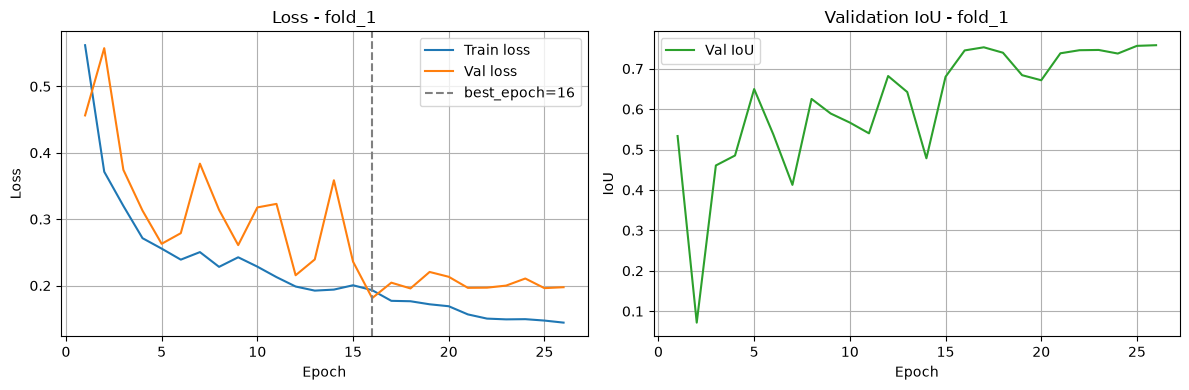

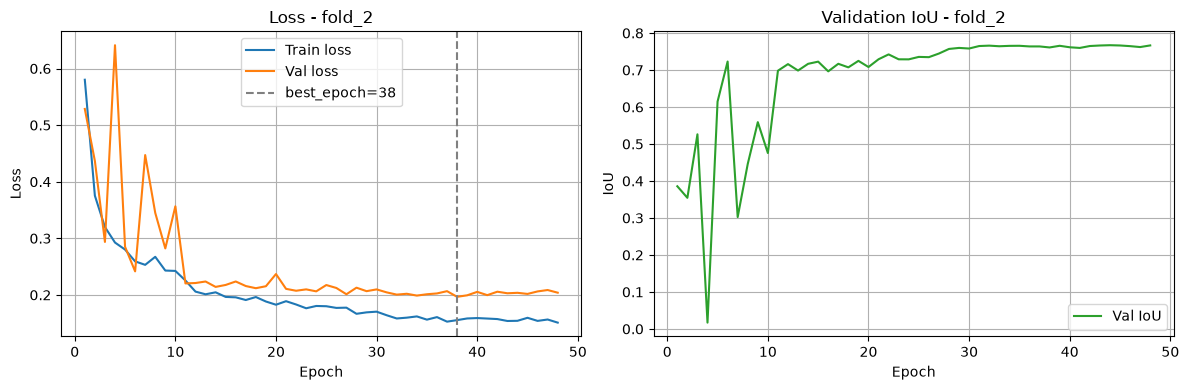

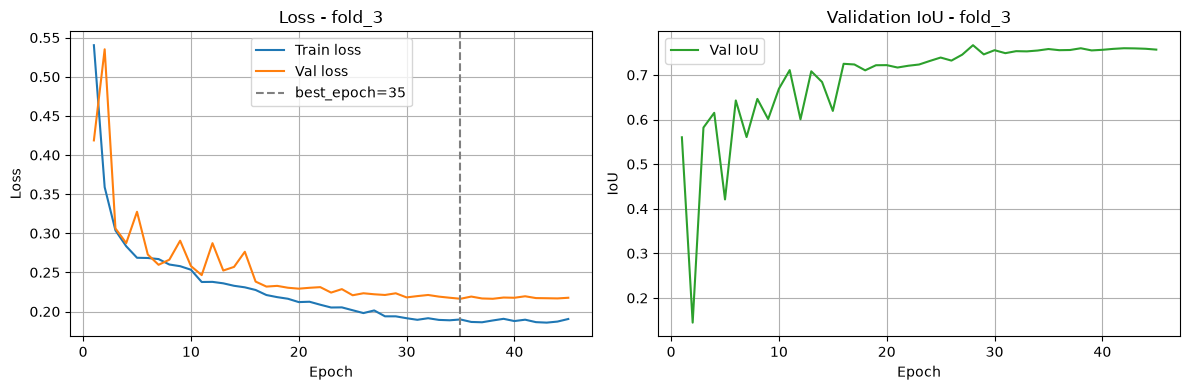

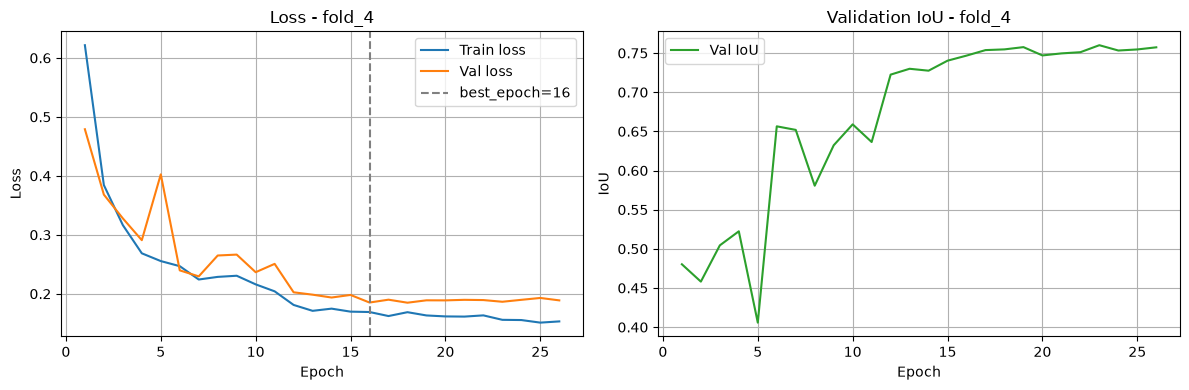

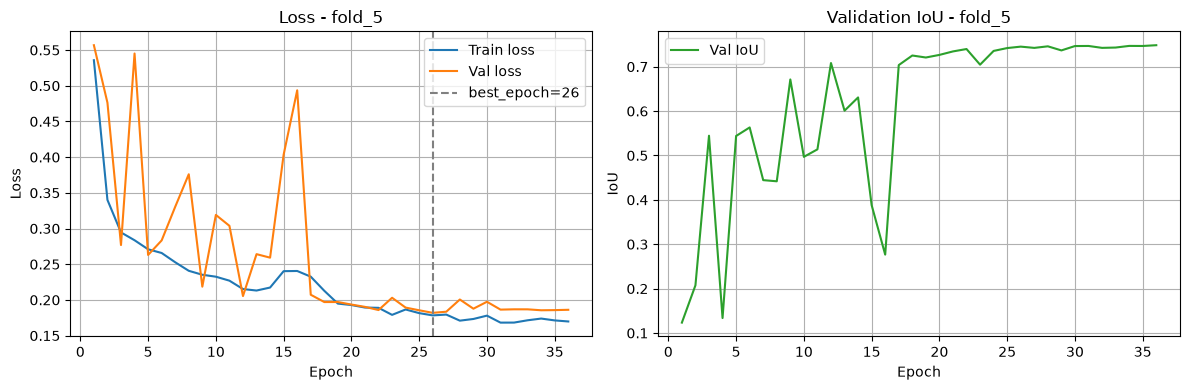

In [20]:
for fold_name, history in fold_histories.items():
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    best_epoch = history["best_epochs"][0] if history["best_epochs"] else 0
    epochs = range(1, len(history["train_loss"]) + 1)
    axs[0].plot(epochs, history["train_loss"], label="Train loss")
    axs[0].plot(epochs, history["val_loss"], label="Val loss")
    if best_epoch:
        axs[0].axvline(best_epoch, color="gray", linestyle="--", label=f"best_epoch={best_epoch}")
    axs[0].set(title=f"Loss - {fold_name}", xlabel="Epoch", ylabel="Loss")
    axs[0].legend(); axs[0].grid(True)
    axs[1].plot(epochs, history["val_iou_all"], label="Val IoU", color="tab:green")
    axs[1].set(title=f"Validation IoU - {fold_name}", xlabel="Epoch", ylabel="IoU")
    axs[1].legend(); axs[1].grid(True)
    plt.tight_layout(); plt.show()


### Sauvegarde des résultats

In [24]:
# Sauvegarde des métriques du meilleur epoch de chaque fold.
with open(f"results_{MODEL_NAME}_{DATASET_NAME}.pkl", "wb") as results_file:
    pickle.dump(fold_results, results_file)


## Résultats validation

Choisir une coupe de validation par son nom de fichier, ou par fold et index. La séquence
et ses deux voisines sont regroupées afin de fournir à CSA-Net le contexte 2,5D attendu.


In [22]:
# ------------ 1. Choix de la coupe -------------
VIS_FILENAME = "0007102_09.42.49_427181_2024.jpg" # Exemple : '0007102_09.42.49_427181_2024.jpg'
VIS_FOLD = 1
VIS_INDEX = 0  # Index parmi les coupes de validation du fold


In [ ]:
# ------------ 2. Construction du triplet et inférence centrale -------------
cv_splits = list(get_cv_splits())
if VIS_FILENAME:
    requested_name = Path(VIS_FILENAME).name
    matches = []
    for fold_index, (_, indices) in enumerate(cv_splits, start=1):
        for local_index, sample_index in enumerate(indices):
            if Path(cv_samples[int(sample_index)]["image_info"]["file_name"]).name == requested_name:
                matches.append((fold_index, local_index, int(sample_index)))
    if len(matches) != 1:
        raise ValueError(f"Le fichier {requested_name} doit correspondre à une seule coupe de validation; correspondances: {matches}")
    VIS_FOLD, VIS_INDEX, sample_index = matches[0]
else:
    if not 1 <= VIS_FOLD <= len(cv_splits):
        raise ValueError(f"VIS_FOLD doit être compris entre 1 et {len(cv_splits)}.")
    _, indices = cv_splits[VIS_FOLD - 1]
    if not 0 <= VIS_INDEX < len(indices):
        raise IndexError(f"VIS_INDEX doit être compris entre 0 et {len(indices) - 1}.")
    sample_index = int(indices[VIS_INDEX])

sample = cv_samples[sample_index]
target_path = sample["image_path"]
_, val_indices = cv_splits[VIS_FOLD - 1]
val_samples = [cv_samples[i] for i in val_indices]
dataset_vis = build_dataset(val_samples)
triplet = next(item for item in dataset_vis if item["image_path"] == target_path)
images = triplet["image"].unsqueeze(0).to(device)
masks = triplet["mask"].unsqueeze(0).to(device)

checkpoint_path = Path(f"saves/unet_finetuned_fold_{VIS_FOLD}_{MODEL_NAME}_{DATASET_NAME}.pth")
if not checkpoint_path.exists():
    raise FileNotFoundError(f"Checkpoint introuvable : {checkpoint_path}")
model_eval = build_model().to(device)
model_eval.load_state_dict(torch.load(checkpoint_path, map_location=device))
model_eval.eval()
with torch.inference_mode(), torch.amp.autocast(device.type, enabled=USE_AMP):
    logits = forward_center_triplet(model_eval, images)

valid_mask = masks != -100
true = (masks > 0.5) & valid_mask
preds = (torch.sigmoid(logits.float()) > 0.5) & valid_mask
if preds.shape[1] > 1:
    preds = fill_holes(keep_largest_components(preds))
preds &= valid_mask

file_name = Path(target_path).name
scale = float(df.loc[df["image_id"] == file_name.split("_")[0], "echelle"].iloc[0])
metrics = metrics_by_class(
    true, preds, torch.tensor([[scale]], device=device), DATASET_NAME
)
intersection, union, iou, dice, precision, recall, diff_surface = metrics
rows = [{"classe": label, "dice": dice[0, index].item(), "iou": iou[0, index].item(),
         "precision": precision[0, index].item(), "recall": recall[0, index].item(),
         "diff_surface (cm²)": diff_surface[0, index].item()}
        for index, label in enumerate(class_names)]
true_global = true[0].sum()
pred_global = preds[0].sum()
intersection_global = intersection.sum()
union_global = union.sum()
rows.append({"classe": "Global",
             "dice": (2 * intersection_global / (true_global + pred_global)).item() if true_global + pred_global > 0 else 1.0,
             "iou": (intersection_global / union_global).item() if union_global > 0 else 1.0,
             "precision": (intersection_global / pred_global).item() if pred_global > 0 else float(true_global == 0),
             "recall": (intersection_global / true_global).item() if true_global > 0 else float(pred_global == 0),
             "diff_surface (cm²)": diff_surface.sum().item()})
display(pd.DataFrame(rows).set_index("classe").style.format(precision=4))
plot_segmentation_comparison(
    triplet["center_image"], true[0].cpu(), preds[0].cpu(), alpha=0.45
)
